In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

import numpy as np
import matplotlib.pyplot as plt

In [8]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

vehicle_classes = [0,1,8,9]
animal_classes = [2,3,4,5,6,7]

y_train_binary = [(1 if label in vehicle_classes else 0) for label in y_train.flatten()]
y_test_binary = [(1 if label in vehicle_classes else 0) for label in y_test.flatten()]

y_train_binary = to_categorical(y_train_binary, 2)
y_test_binary = to_categorical(y_test_binary, 2)

x_train, x_test = x_train/255.0, x_test/255.0

In [9]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(2, activation="softmax")
])

c:\Users\flori\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(x_train, y_train_binary, epochs=10,
                    validation_data=(x_test, y_test_binary))

test_loss, test_acc = model.evaluate(x_test, y_test_binary, verbose=20)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8770 - loss: 0.2922 - val_accuracy: 0.8989 - val_loss: 0.2395
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9100 - loss: 0.2250 - val_accuracy: 0.9178 - val_loss: 0.2035
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9191 - loss: 0.2020 - val_accuracy: 0.9115 - val_loss: 0.2153
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9267 - loss: 0.1840 - val_accuracy: 0.9225 - val_loss: 0.2014
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9325 - loss: 0.1701 - val_accuracy: 0.9278 - val_loss: 0.1808
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9395 - loss: 0.1546 - val_accuracy: 0.9306 - val_loss: 0.1848
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9454 - loss: 0.1389 - val_accuracy: 0.9277 - val_loss: 0.1826
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9498 - loss: 0.126

In [11]:
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(x_test)
def display_prediction(index):
    plt.imshow(x_test[index])
    plt.axis("off")
    actual_label = "Vehicle" if np.argmax(y_test_binary[index]) == 1 else "Animal"
    predicted_label = "Vehicle" if np.argmax(predictions[index]) == 1 else "Animal"
    plt.title("Actual: {actual_label}, Predicted: {predicted_label}")
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


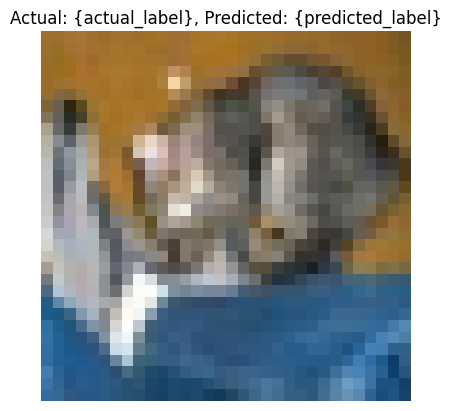

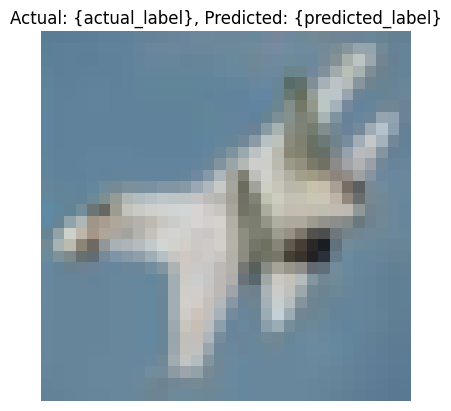

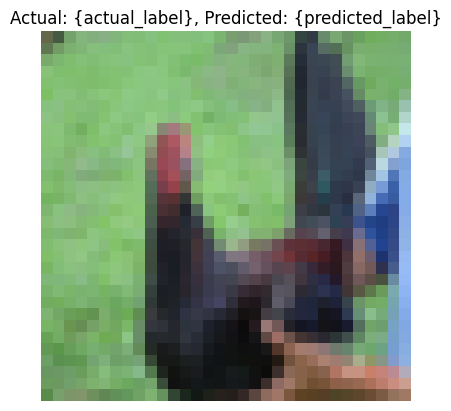

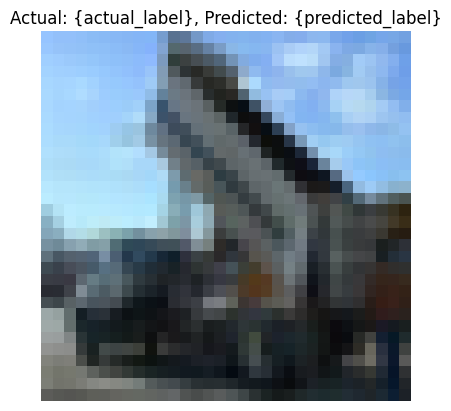

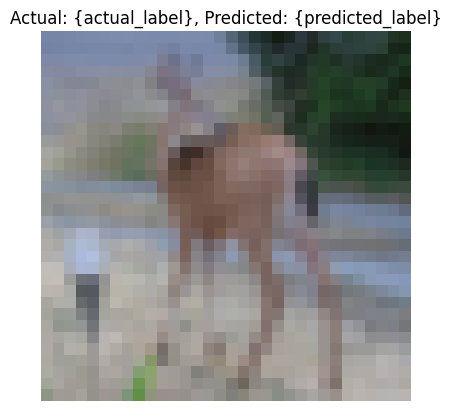

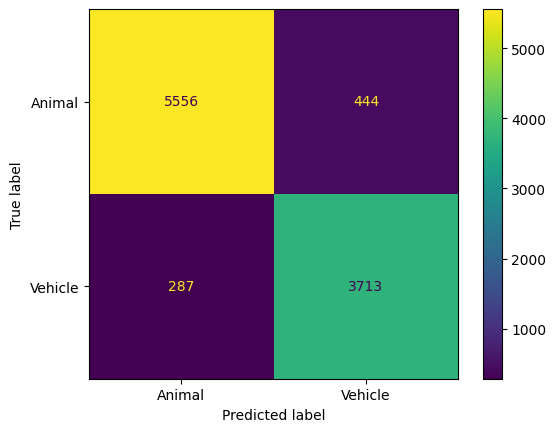

In [12]:
for i in [0,10,25,50,100]:
    display_prediction(i)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(y_test_binary, axis=1)

cm = confusion_matrix(actual_classes, predicted_classes)
ConfusionMatrixDisplay(cm,display_labels=["Animal","Vehicle"]).plot()
plt.show()